# Makemore

[https://github.com/karpathy/makemore](https://github.com/karpathy/makemore)

## Import & Loading data

In [48]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt

In [9]:
with open("../../Datasets/makemore_names.txt", "r", encoding="utf-8") as file:
    content = file.read()
names = content.splitlines()
print(len(names), names[:5])

32033 ['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [13]:
min_len_word = min([len(w) for w in names])
max_len_word = max([len(w) for w in names])
(min_len_word, max_len_word)

(2, 15)

In [23]:
chars = set()
for w in names:
    for c in w:
        chars.add(c)
chars = sorted(chars)
chars = ["."] + chars # . (dot) is the start and end of the word, to maintain the character
print(f"Individual characters: {chars}\ntotal chars: {len(chars)}")

Individual characters: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
total chars: 27


In [38]:
itos = {idx:c for idx, c in enumerate(chars)}
stoi = {c:idx for idx, c in enumerate(chars)}
total_chars = len(itos)
print(f"Index to chars: {itos}")
print(f"Chars to Index: {stoi}")
print(len(itos))

Index to chars: {0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}
Chars to Index: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
27


In [25]:
list(names[0])

['e', 'm', 'm', 'a']

## Bigram Model

In [217]:
P = torch.zeros((total_chars, total_chars), dtype=torch.float32)
for n in names:
    n = "." + n + "."
    for c1, c2 in zip(n, n[1:]):
        P[stoi[c1], stoi[c2]] += 1

In [218]:
P.size()

torch.Size([27, 27])

In [219]:
P[0]

tensor([   0., 4410., 1306., 1542., 1690., 1531.,  417.,  669.,  874.,  591.,
        2422., 2963., 1572., 2538., 1146.,  394.,  515.,   92., 1639., 2055.,
        1308.,   78.,  376.,  307.,  134.,  535.,  929.])

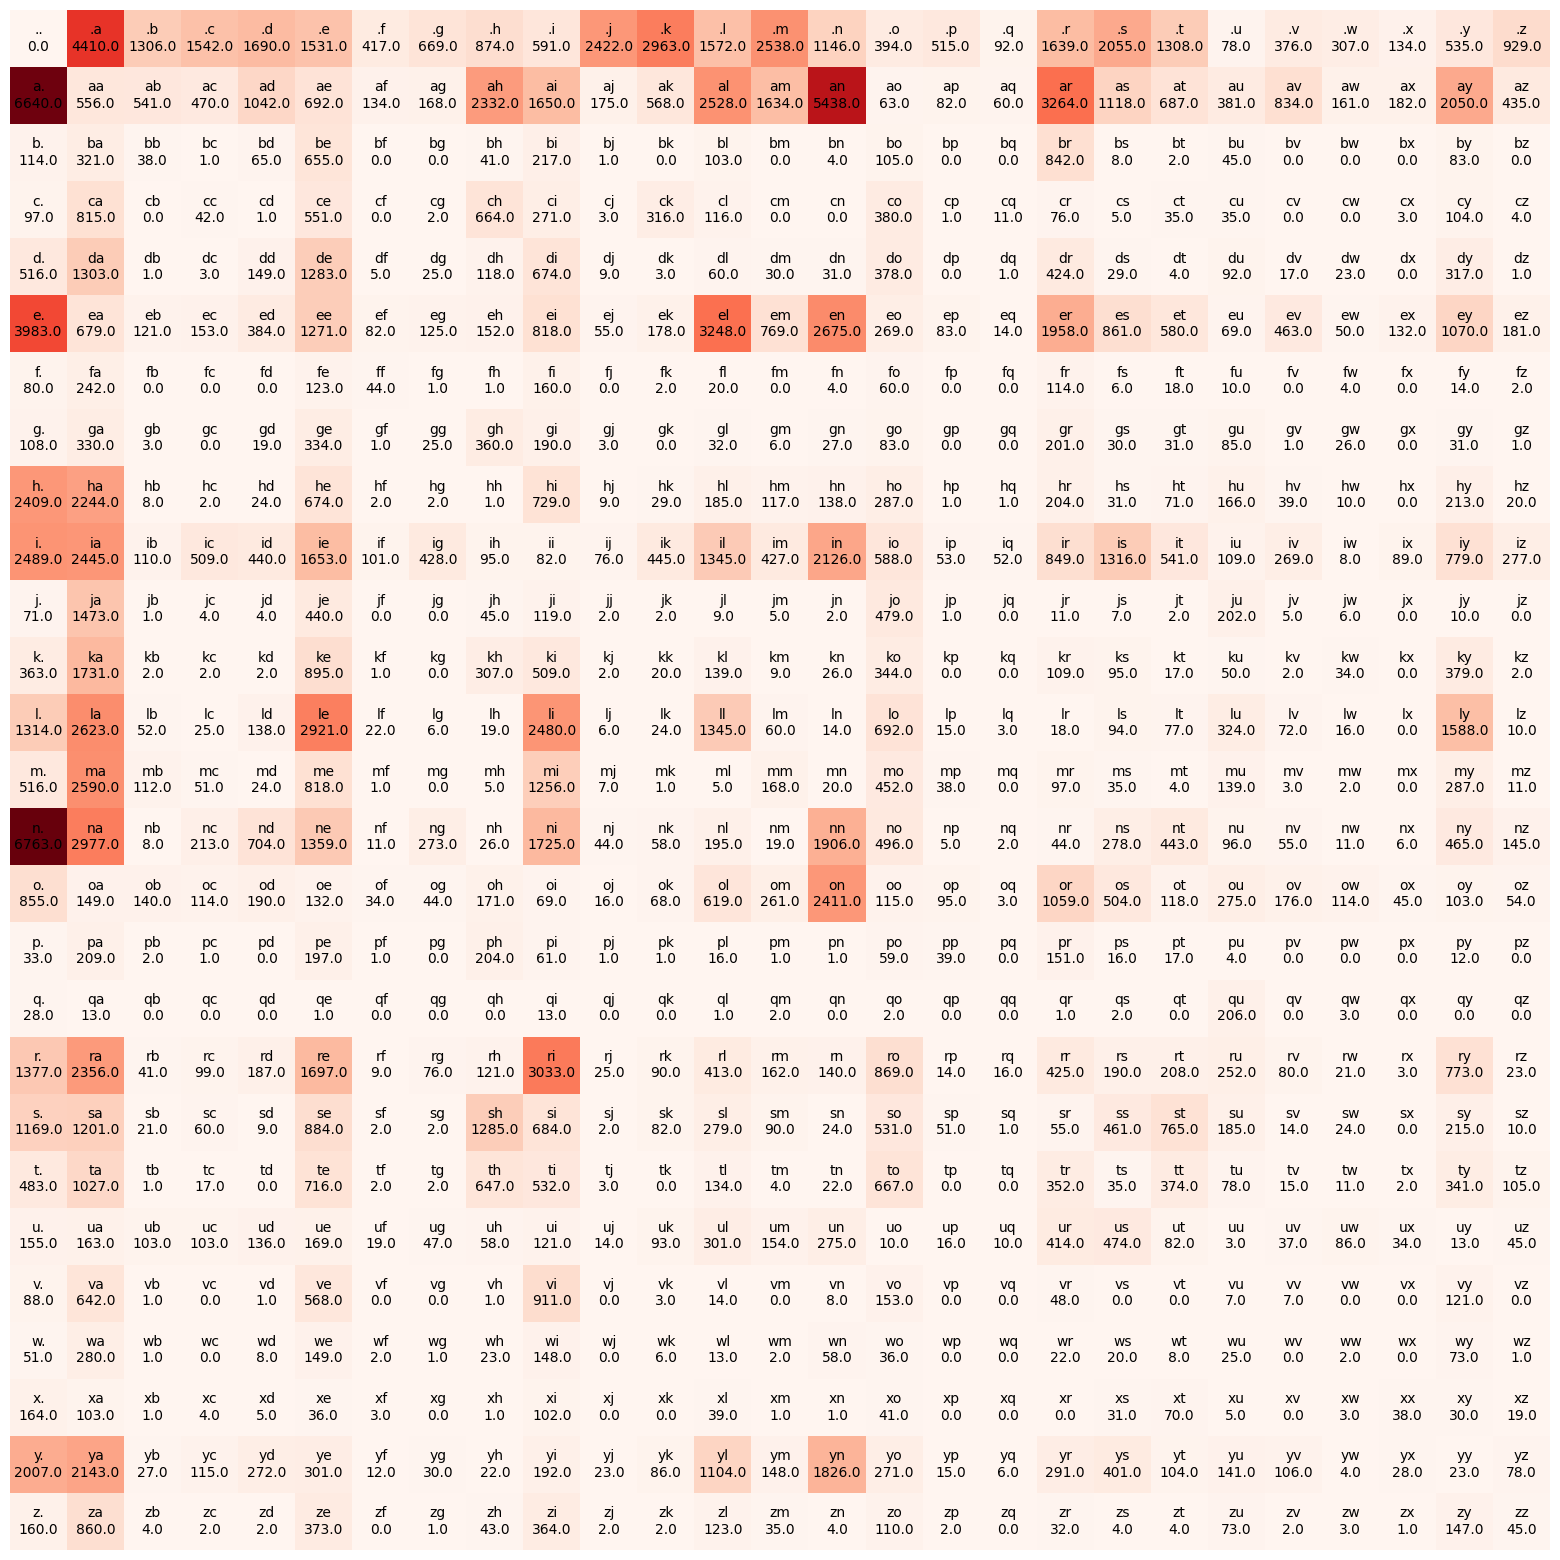

In [220]:
plt.figure(figsize=(20,20))
plt.imshow(P, cmap='Reds')
for i in range(total_chars):
    for j in range(total_chars):
        plt.text(j, i, f"{itos[i]}{itos[j]}\n{P[i,j].item()}", ha="center", va="center")
plt.axis("off")
plt.show()

In [221]:
# Normalize it
P += 1.0 # to handle later in the loss, to not have 0.0 during loss calculation as log(0) = -inf
P /= P.sum(dim=1, keepdim=True)

In [222]:
P[0].sum()

tensor(1.)

In [223]:
g = torch.Generator().manual_seed(2147483647)
t = torch.rand(3, generator=g)
t / t.sum()

tensor([0.6064, 0.3033, 0.0903])

In [224]:
sample_idx = torch.multinomial(t,num_samples=100, replacement=True, generator=g)
elts, cnts = sample_idx.unique(return_counts=True)
print(f"Sampled Indices: {sample_idx}")
print(elts,cnts)
print(cnts/cnts.sum())

Sampled Indices: tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])
tensor([0, 1, 2]) tensor([61, 33,  6])
tensor([0.6100, 0.3300, 0.0600])


In [225]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    #predicting a new word
    cidx = 0
    w = itos[cidx]

    while True:
        cidx = torch.multinomial(P[cidx], num_samples=1, replacement=True, generator=g).item()
        w += itos[cidx]
        if itos[cidx] == '.':
            break
    print(w[1:-1])

cexze
momasurailezitynn
konimittain
llayn
ka


In [216]:
# finding the prob of next char prediction
for n in names[:3]:
    n = '.' + n + '.'
    for c1, c2 in zip(n, n[1:]):
        prob = P[stoi[c1], stoi[c2]]
        print(f"{c1}{c2} - {prob:.4f} - {-torch.log(prob)}")

.e - 0.0478 - 3.0410351753234863
em - 0.0377 - 3.2793476581573486
mm - 0.0253 - 3.6753265857696533
ma - 0.3885 - 0.9454260468482971
a. - 0.1958 - 1.6305063962936401
.o - 0.0123 - 4.396478652954102
ol - 0.0779 - 2.5525903701782227
li - 0.1774 - 1.7293236255645752
iv - 0.0152 - 4.184478759765625
vi - 0.3508 - 1.0476267337799072
ia - 0.1380 - 1.9806911945343018
a. - 0.1958 - 1.6305063962936401
.a - 0.1376 - 1.983507752418518
av - 0.0246 - 3.704092502593994
va - 0.2473 - 1.3971220254898071
a. - 0.1958 - 1.6305063962936401


In [204]:
def loss(P, words):
    nll = 0.0
    n = 0
    for word in words:
        word = '.'+word+'.'
        for c1, c2 in zip(word, word[1:]):
            prob = P[stoi[c1], stoi[c2]] #likelihood, which is the probability
            loglikelihood = torch.log(prob) #log likelihood
            nll += -loglikelihood #negative log likelihood
            #print(f"{c1}{c2} - {prob:.4f} {-torch.log(prob)}")
            n += 1
    #print(nll)
    #print(nll/n) #normalize the nll
    return nll/n
    
train_loss = loss(P, names)
print(f"Training data loss: {train_loss}")

Training data loss: 2.4543561935424805


## Simple NN model

We are going with (nx27) - (27x27) simple neural network

In [1]:
import torch
import torch.nn.functional as F
import numpy as np

In [2]:
with open("../../Datasets/makemore_names.txt", "r", encoding="utf-8") as file:
    content = file.read()
words = content.splitlines()
print(len(words), words[:5])

32033 ['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [4]:
chars = set()
for w in words:
    for c in w:
        chars.add(c)
chars = sorted(chars)
chars = ["."] + chars # . (dot) is the start and end of the word, to maintain the character
print(f"Individual characters: {chars}\ntotal chars: {len(chars)}")

Individual characters: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
total chars: 27


In [5]:
itos = {idx:c for idx, c in enumerate(chars)}
stoi = {c:idx for idx, c in enumerate(chars)}
total_chars = len(itos)
print(f"Index to chars: {itos}")
print(f"Chars to Index: {stoi}")
print(len(itos))

Index to chars: {0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}
Chars to Index: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
27


In [6]:
xs, ys = [], []
for w in words:
    w = "."+w+"."
    for c1, c2 in zip(w, w[1:]):
        #print (c1, c2)
        xs.append(stoi[c1])
        ys.append(stoi[c2])
n = len(xs)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(n)

228146


In [7]:
xs[0], ys[0]

(tensor(0), tensor(5))

In [8]:
xenc = F.one_hot(xs, num_classes=total_chars).float()
yenc = F.one_hot(ys, num_classes=total_chars)
print(xenc.shape)
print(xenc[:5])

torch.Size([228146, 27])
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])


In [9]:

# Neural Network
g = torch.Generator().manual_seed(2147483647)

W = torch.randn((total_chars, total_chars), generator=g, requires_grad=True)
print((xenc[:5] @ W).shape)

torch.Size([5, 27])


In [10]:
logits = xenc @ W
exp = logits.exp()
probs = exp / exp.sum(dim=1, keepdim=True)
print(probs[0], probs[0].sum())
probs.shape

tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>) tensor(1.0000, grad_fn=<SumBackward0>)


torch.Size([228146, 27])

In [11]:
loss = -torch.log(probs[0,ys[0]])
loss

tensor(4.3993, grad_fn=<NegBackward0>)

In [12]:
probs[torch.arange(0, len(probs)), ys]

tensor([0.0123, 0.0181, 0.0267,  ..., 0.0111, 0.0833, 0.0308],
       grad_fn=<IndexBackward0>)

In [22]:
#training
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((total_chars, total_chars), generator=g, requires_grad=True)

for i in range(50):
    
    # forward pass
    logits = xenc @ W
    exp = logits.exp()
    probs = exp / exp.sum(dim=1, keepdim=True)
    
    # find loss
    ypred = probs[torch.arange(0, len(probs)) , ys]
    loss = -torch.log(ypred).mean() + 0.01*(W**2).mean()
    print(loss.item())
    
    # grad zero
    W.grad = None
    
    # backproper
    loss.backward()
    W.data += -50*W.grad 

3.7686190605163574
3.3787858486175537
3.1610772609710693
3.027181386947632
2.9344801902770996
2.8672285079956055
2.816653251647949
2.7771458625793457
2.745253562927246
2.7188305854797363
2.696505546569824
2.6773722171783447
2.6608054637908936
2.6463515758514404
2.633665084838867
2.622471332550049
2.6125471591949463
2.6037063598632812
2.595794439315796
2.5886809825897217
2.5822560787200928
2.5764293670654297
2.5711233615875244
2.566272497177124
2.5618226528167725
2.5577261447906494
2.5539441108703613
2.550442695617676
2.547192335128784
2.5441696643829346
2.5413525104522705
2.538722038269043
2.536262035369873
2.5339579582214355
2.531797409057617
2.529768228530884
2.527860164642334
2.5260636806488037
2.5243709087371826
2.522773265838623
2.52126407623291
2.519836664199829
2.5184857845306396
2.5172054767608643
2.515990972518921
2.5148372650146484
2.5137410163879395
2.51269793510437
2.511704921722412
2.5107579231262207


In [29]:
F.one_hot(torch.tensor(0), num_classes=total_chars)

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [55]:
#Generate samples now
g = torch.Generator().manual_seed(2147483647)
n = 2
for i in range(5):
    idx = 0
    word = []
    while True:
        with torch.no_grad():
            xin = F.one_hot(torch.tensor(idx), num_classes=total_chars).float()
            #print(xin.shape)
            logits = xin @ W
            #print(logits.shape)
            exp = logits.exp()
            #print(exp, exp.shape)
            prob = (exp / exp.sum()) #prob array
            #print(prob)
            
            idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=g)
            idx = idx.item()
            word.append(itos[idx])
            #print(idx)
            #print(itos[idx])
            
        if idx == 0:
            break
    print("".join(word[:-1]))
    

cexze
mogllurailezityha
konimittain
llayn
ka


output is same as before

## MLP Based model

[https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

![](../../Images/mlp-yoshua.png)

### Prerequisites

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [2]:
names = open("../../Datasets/makemore_names.txt", "r").read().splitlines()
print(names)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [3]:
itos = {}
stoi = {}
num_chars = 0
letters = set()
letters.add(".")
for n in names:
    for c in n:
        letters.add(c)
letters = list(sorted(letters))
num_chars = len(letters)

for idx, l in enumerate(letters):
    itos[idx] = l
    stoi[l] = idx
print(f"{itos}, \n{stoi}")

{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}, 
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


### Model

In [35]:
block_size = 3
xs, ys = [], []
for n in names[:5]:
    n = ["."] * block_size + list(n) + ["."]
    for i in range(0, len(n)-block_size):
        tx = n[i:i+block_size]
        ty = n[i+block_size]
        xs.append([stoi[_] for _ in tx])
        ys.append(stoi[n[i+block_size]])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(xs[:5])
print(ys[:5])

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]])
tensor([ 5, 13, 13,  1,  0])


In [36]:
print(xs.shape, ys.shape)

torch.Size([32, 3]) torch.Size([32])


In [38]:
C = torch.randn(size=(num_chars, 2))
C.shape

torch.Size([27, 2])

In [41]:
C[xs].shape

torch.Size([32, 3, 2])

In [43]:
C[xs].view(size=(-1,6)).shape

torch.Size([32, 6])

In [49]:
W1 = torch.randn(size=(6, 100))
(C[xs].view(size=(-1,6)) @ W1).shape

torch.Size([32, 100])

In [55]:
b1 = torch.randn(100)
(C[xs].view(size=(-1,6)) @ W1 + b1).shape

torch.Size([32, 100])

In [56]:
(C[xs].view(size=(-1,6)) @ W1 + b1).tanh().shape

torch.Size([32, 100])

In [61]:
W2 = torch.randn(size=(100,27))
b2 = torch.rand(27)

logits = ((((C[xs].view(size=(-1,6)) @ W1 + b1).tanh()) @ W2)+b2)
logits.shape

torch.Size([32, 27])

In [62]:
logits[0]

tensor([ -6.5659, -12.2091,  16.6166,  -4.7163,  -0.1269,   0.0760,   3.7093,
          4.6930,  13.5013, -12.7108,   5.5713,   0.0513,  11.4615,   4.1652,
          0.2639,  10.9293,  -6.6654,   0.3837,   9.0989,   4.5620,   4.2857,
          0.3178,  -2.6883,  -3.2783,   9.4994,   4.4806,   0.4240])

In [65]:
loss = F.cross_entropy(logits[0], ys[0])
loss

tensor(16.5940)

In [66]:
ys.shape

torch.Size([32])

In [67]:
F.cross_entropy(logits, ys)

tensor(17.9199)

### Proper Implementation of the model

In [68]:
block_size = 3
xs, ys = [], []
for n in names:
    n = ["."] * block_size + list(n) + ["."]
    for i in range(0, len(n)-block_size):
        tx = n[i:i+block_size]
        ty = n[i+block_size]
        xs.append([stoi[_] for _ in tx])
        ys.append(stoi[n[i+block_size]])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(xs.shape)
print(ys.shape)

torch.Size([228146, 3])
torch.Size([228146])


In [80]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [C, W1, b1, W2, b2]

In [81]:
for p in params:
    p.requires_grad = True

In [82]:
for _ in range(1000):
    
    # forward pass
    l1 = (C[xs].view(-1, 6)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    
    # compute loss
    loss = F.cross_entropy(logits, ys)
    
    # backprop
    for p in params:
        p.grad = None
    loss.backward()
    
    for p in params:
        p.data += -0.1 * p.grad
    if _ % 50 == 0:
        print(f"Epoch: {_} loss:{loss.item()}")

Epoch: 0 loss:19.505229949951172
Epoch: 50 loss:5.105464935302734
Epoch: 100 loss:3.5755462646484375
Epoch: 150 loss:3.153400182723999
Epoch: 200 loss:2.9601340293884277
Epoch: 250 loss:2.8551368713378906
Epoch: 300 loss:2.7912745475769043
Epoch: 350 loss:2.7485439777374268
Epoch: 400 loss:2.7174692153930664
Epoch: 450 loss:2.6924803256988525
Epoch: 500 loss:2.6703052520751953
Epoch: 550 loss:2.6497914791107178
Epoch: 600 loss:2.631375789642334
Epoch: 650 loss:2.6158182621002197
Epoch: 700 loss:2.603259563446045
Epoch: 750 loss:2.5931804180145264
Epoch: 800 loss:2.584852695465088
Epoch: 850 loss:2.5777218341827393
Epoch: 900 loss:2.5714645385742188
Epoch: 950 loss:2.565892457962036


In [89]:
loss.item()

2.5609700679779053

In [116]:
g = torch.Generator().manual_seed(2147483647)
# inference
for i in range(10):
    
    #Initial block
    block = ['.'] * block_size
    idx = [stoi[b] for b in block]
    word = []
    
    while True:
        with torch.no_grad():
            # forward pass
            l1 = C[idx].view(-1, 6) @ W1 + b1
            l2 = l1.tanh()
            logits = l2 @ W2 + b2
            exp = logits.exp()
            prob = exp / exp.sum(dim=1, keepdim=True)
            
            next_idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()
            #print(next_idx)
            
            if next_idx == 0:
                break
            
            word.append(itos[next_idx])
            
            block = block[1:] + [itos[next_idx]]
            idx = [stoi[b] for b in block]
    print("".join(word))

dex
malealsuraila
kayha
molimitna
nrllzan
kan
a
samiyauelansr
gotas
moziellaxo


### Hyper parameter tuning

In [118]:
xs.shape, ys.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [4]:
len(names), int(len(names)*.8), int(len(names)*.1)

(32033, 25626, 3203)

In [5]:
# SPlit the data
def build_dataset(names, block_size = 3):
    xs, ys = [], []
    for n in names:
        n = ["."] * block_size + list(n) + ["."]
        for i in range(0, len(n)-block_size):
            tx = n[i:i+block_size]
            ty = n[i+block_size]
            xs.append([stoi[_] for _ in tx])
            ys.append(stoi[n[i+block_size]])

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    
    return xs, ys

In [6]:
n1 = (0, int(len(names)*.8))
n2 = (int(len(names)*.8), int(len(names)*.1)+int(len(names)*.8))
n3 = ( int(len(names)*.1)+int(len(names)*.8), len(names))

xtr, ytr = build_dataset(names[n1[0]: n1[1]])
xdev, ydev = build_dataset(names[n2[0]: n2[1]])
xte, yte = build_dataset(names[n3[0]: n3[1]])

print(f"Train shape: {xtr.shape}, dev shape: {xdev.shape}, test shape: {xte.shape}")

Train shape: torch.Size([182778, 3]), dev shape: torch.Size([22633, 3]), test shape: torch.Size([22735, 3])


In [9]:
lrs = torch.linspace(start=-3, end=0, steps=100) ##learning rates
lre = torch.exp(lrs)
lre

tensor([0.0498, 0.0513, 0.0529, 0.0545, 0.0562, 0.0579, 0.0597, 0.0616, 0.0634,
        0.0654, 0.0674, 0.0695, 0.0716, 0.0738, 0.0761, 0.0784, 0.0809, 0.0833,
        0.0859, 0.0885, 0.0913, 0.0941, 0.0970, 0.1000, 0.1030, 0.1062, 0.1095,
        0.1128, 0.1163, 0.1199, 0.1236, 0.1274, 0.1313, 0.1353, 0.1395, 0.1438,
        0.1482, 0.1528, 0.1575, 0.1623, 0.1673, 0.1725, 0.1778, 0.1832, 0.1889,
        0.1947, 0.2007, 0.2069, 0.2132, 0.2198, 0.2265, 0.2335, 0.2407, 0.2481,
        0.2557, 0.2636, 0.2717, 0.2801, 0.2887, 0.2976, 0.3067, 0.3162, 0.3259,
        0.3359, 0.3462, 0.3569, 0.3679, 0.3792, 0.3909, 0.4029, 0.4153, 0.4281,
        0.4412, 0.4548, 0.4688, 0.4832, 0.4981, 0.5134, 0.5292, 0.5455, 0.5623,
        0.5796, 0.5974, 0.6158, 0.6347, 0.6543, 0.6744, 0.6951, 0.7165, 0.7386,
        0.7613, 0.7847, 0.8089, 0.8338, 0.8594, 0.8858, 0.9131, 0.9412, 0.9702,
        1.0000])

In [105]:
# parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

Loss: 2.8217411041259766


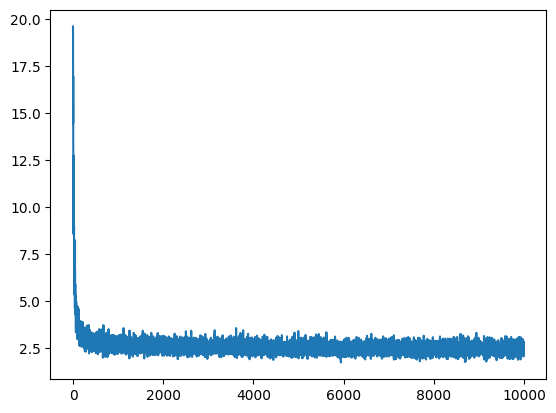

In [106]:
## Minibatch
losses = []
mini_batch_size = 64
epochs = 10000

for i in range(epochs):
    
    ix = torch.randint(low=0, high=xtr.shape[0], size=(32,))
    
    # forward pass
    l1 = (C[xtr[ix]].view(-1, 6)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    
    # compute loss
    loss = F.cross_entropy(logits, ytr[ix])
    
    # backprop
    for p in params:
        p.grad = None
    loss.backward()
    
    for p in params:
        p.data += - 0.1 * p.grad
    losses.append(loss.item())

print(f"Loss: {loss}")
plt.plot(torch.arange(start=0, end=len(losses), step=1), losses)
plt.show()

In [107]:
# parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

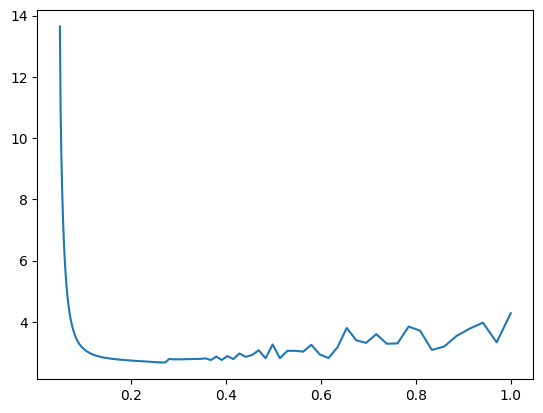

In [108]:
losses = []
for lr in lre:
    for i in range(10):
        
        # forward pass
        l1 = (C[xdev].view(-1, 6)) @ W1 + b1
        l2 = l1.tanh()
        logits = l2 @ W2 + b2
        
        # compute loss
        loss = F.cross_entropy(logits, ydev)
        
        # backprop
        for p in params:
            p.grad = None
        loss.backward()
        
        for p in params:
            p.data += - lr * p.grad
    losses.append(loss.item())
plt.plot(lre, losses)
plt.show()

In [114]:
#let's choose 0.2 as learning rate
lr = 0.26
losses = []

# parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

In [138]:
lr = 0.02
for i in range(10000):
    
    ix = torch.randint(low=0, high=xtr.shape[0], size=(64,))
    
    # forward pass
    l1 = (C[xtr[ix]].view(-1, 6)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    
    # compute loss
    loss = F.cross_entropy(logits, ytr[ix])
    
    # backprop
    for p in params:
        p.grad = None
    loss.backward()
    
    for p in params:
        p.data += - lr * p.grad
    losses.append(loss.item())

print(loss)

tensor(2.0699, grad_fn=<NllLossBackward0>)


In [139]:
with torch.no_grad():
    l1 = (C[xtr].view(-1, 6)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    train_loss = F.cross_entropy(logits, ytr)
    
    l1 = (C[xdev].view(-1, 6)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    dev_loss = F.cross_entropy(logits, ydev)
    
print(f"Training Loss: {train_loss}")
print(f"Dev Loss: {dev_loss}")

Training Loss: 2.1663670539855957
Dev Loss: 2.4296116828918457


### Latest Andrej's benchmark

![](../../Images/andrej-mlp-makemore-benchmark.png)

In [184]:
num_chars

27

In [197]:
# Let's increase the network size
losses = []

# parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200,num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True
    
print(f"No of params: {sum([p.nelement() for p in params])}")

No of params: 11897


In [201]:
lr = 0.01
for i in range(50000):
    
    ix = torch.randint(low=0, high=xtr.shape[0], size=(32,))
    
    # forward pass
    l1 = (C[xtr[ix]].view(-1, 30)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    
    # compute loss
    loss = F.cross_entropy(logits, ytr[ix])
    
    # backprop
    for p in params:
        p.grad = None
    loss.backward()
    
    for p in params:
        p.data += - lr * p.grad
    losses.append(loss.item())

print(f"Minibatch loss: {loss}")

with torch.no_grad():
    l1 = (C[xtr].view(-1, 30)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    train_loss = F.cross_entropy(logits, ytr)
    
    l1 = (C[xdev].view(-1, 30)) @ W1 + b1
    l2 = l1.tanh()
    logits = l2 @ W2 + b2
    dev_loss = F.cross_entropy(logits, ydev)
    
print(f"Training Loss: {train_loss}")
print(f"Dev Loss: {dev_loss}")

Minibatch loss: 2.261781692504883
Training Loss: 2.1071088314056396
Dev Loss: 2.420797348022461


Batchsize = 32

lr = 0.1
Minibatch loss: 2.0832974910736084
Training Loss: 2.3045194149017334
Dev Loss: 2.588442802429199

lr = 0.01
Minibatch loss: 1.9877938032150269
Training Loss: 2.1237375736236572
Dev Loss: 2.4391255378723145

lr = 0.01 2nd iteration
Minibatch loss: 2.245054006576538
Training Loss: 2.116502523422241
Dev Loss: 2.42856502532959


lr = 0.01 3rd iteration
Minibatch loss: 2.261781692504883
Training Loss: 2.1071088314056396
Dev Loss: 2.420797348022461

Batchsize = 64

lr = 0.1
Minibatch loss: 2.1567015647888184
Training Loss: 2.225172996520996
Dev Loss: 2.5544514656066895

lr = 0.01
Minibatch loss: 2.312218189239502
Training Loss: 2.119206428527832
Dev Loss: 2.426419973373413

lr = 0.01 2nd iteration
Minibatch loss: 1.8205350637435913
Training Loss: 2.1115381717681885
Dev Loss: 2.4166617393493652

lr = 0.01 3rd iteration
Minibatch loss: 2.0659291744232178
Training Loss: 2.1059410572052
Dev Loss: 2.415149688720703



In [206]:
block_size = 3
g = torch.Generator().manual_seed(2147483647)
# inference
for i in range(10):
    
    #Initial block
    block = ['.'] * block_size
    idx = [stoi[b] for b in block]
    word = []
    
    while True:
        with torch.no_grad():
            # forward pass
            l1 = C[idx].view(-1, 30) @ W1 + b1
            l2 = l1.tanh()
            logits = l2 @ W2 + b2
            exp = logits.exp()
            prob = exp / exp.sum(dim=1, keepdim=True)
            
            next_idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()
            #print(next_idx)
            
            if next_idx == 0:
                break
            
            word.append(itos[next_idx])
            
            block = block[1:] + [itos[next_idx]]
            idx = [stoi[b] for b in block]
    print("".join(word))

dex
malompsurailah
tyha
malimitta
nolla
kama
darreen
peejahhi
gotti
molie


### Optimizing the code

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
names = open("../../Datasets/makemore_names.txt", "r").read().splitlines()
print(names)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [3]:
itos = {}
stoi = {}
num_chars = 0
letters = set()
letters.add(".")
for n in names:
    for c in n:
        letters.add(c)
letters = list(sorted(letters))
num_chars = len(letters)

for idx, l in enumerate(letters):
    itos[idx] = l
    stoi[l] = idx
print(f"{itos}, \n{stoi}")

{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}, 
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


In [4]:
# SPlit the data
def build_dataset(names, block_size = 3):
    xs, ys = [], []
    for n in names:
        n = ["."] * block_size + list(n) + ["."]
        for i in range(0, len(n)-block_size):
            tx = n[i:i+block_size]
            ty = n[i+block_size]
            xs.append([stoi[_] for _ in tx])
            ys.append(stoi[n[i+block_size]])

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    
    return xs, ys


n1 = (0, int(len(names)*.8))
n2 = (int(len(names)*.8), int(len(names)*.1)+int(len(names)*.8))
n3 = ( int(len(names)*.1)+int(len(names)*.8), len(names))

xtr, ytr = build_dataset(names[n1[0]: n1[1]])
xdev, ydev = build_dataset(names[n2[0]: n2[1]])
xte, yte = build_dataset(names[n3[0]: n3[1]])

print(f"Train shape: {xtr.shape}, dev shape: {xdev.shape}, test shape: {xte.shape}")

Train shape: torch.Size([182778, 3]), dev shape: torch.Size([22633, 3]), test shape: torch.Size([22735, 3])


In [77]:
# Let's increase the network size
hidden_units = 200
emb_size = 10
losses = []

# parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,emb_size), generator=g)
W1 = torch.randn((3*emb_size,hidden_units), generator=g) * (5/3)/((3*emb_size)**.5) # He initialization
b1 = torch.randn(hidden_units, generator=g) * 0.01 
# typically b1 is not needed as we have bbias in the batch norm of the hidden layer, batch norm will remove this mean

W2 = torch.randn((hidden_units,num_chars), generator=g) * 0.01
b2 = torch.randn(num_chars, generator=g) * 0

bscale = torch.ones(hidden_units)
bbias = torch.zeros(hidden_units)

dmean = torch.zeros(hidden_units)
dstd = torch.ones(hidden_units)

params = [C, W1, b1, W2, b2, bscale, bbias]
for p in params:
    p.requires_grad = True
    
print(f"No of params: {sum([p.nelement() for p in params])}")

No of params: 12297


In [78]:
epochs = 200000
epsilon = 0.00001

for i in range(epochs):
    
    ix = torch.randint(low=0, high=xtr.shape[0], size=(32,), generator=g)
    
    # forward pass
    l1 = (C[xtr[ix]].view(-1, 3*emb_size)) @ W1 + b1
    
    ## batch norm
    bmean = l1.mean(dim=0, keepdim=True)
    bstd = l1.std(dim=0, keepdim=True) + epsilon
    l1_norm = bscale * (l1 - bmean)/bstd + bbias
    
    with torch.no_grad():
       dmean = .999 * dmean + 0.001 * bmean
       dstd  = .999 * dstd  + 0.001 * bstd
    
    l2 = l1_norm.tanh()
    logits = l2 @ W2 + b2
    
    # compute loss
    loss = F.cross_entropy(logits, ytr[ix])
    
    if i%10000 == 0:
        print(f"epoch {i}, mini-batch loss:{loss.item():.4f}")
    
    # backprop
    for p in params:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in params:
        p.data += - lr * p.grad
    losses.append(loss.item())

print(f"Minibatch loss: {loss:.4f}")

epoch 0, mini-batch loss:3.3442
epoch 10000, mini-batch loss:2.1095
epoch 20000, mini-batch loss:1.9760
epoch 30000, mini-batch loss:1.7753
epoch 40000, mini-batch loss:2.0790
epoch 50000, mini-batch loss:1.9369
epoch 60000, mini-batch loss:2.5229
epoch 70000, mini-batch loss:2.4514
epoch 80000, mini-batch loss:1.7932
epoch 90000, mini-batch loss:2.2978
epoch 100000, mini-batch loss:2.1749
epoch 110000, mini-batch loss:2.0796
epoch 120000, mini-batch loss:1.9102
epoch 130000, mini-batch loss:1.9998
epoch 140000, mini-batch loss:2.1022
epoch 150000, mini-batch loss:2.3006
epoch 160000, mini-batch loss:1.9463
epoch 170000, mini-batch loss:2.1586
epoch 180000, mini-batch loss:2.1738
epoch 190000, mini-batch loss:1.7376
Minibatch loss: 2.2103


In [79]:
with torch.no_grad():
    l1 = (C[xtr].view(-1, 3*emb_size)) @ W1 + b1
    l1_norm = bscale * (l1 - dmean)/dstd + bbias
    l2 = l1_norm.tanh()
    logits = l2 @ W2 + b2
    train_loss = F.cross_entropy(logits, ytr)
    
    l1 = (C[xdev].view(-1, 3*emb_size)) @ W1 + b1
    l1_norm = bscale * (l1 - dmean)/dstd + bbias
    l2 = l1_norm.tanh()
    logits = l2 @ W2 + b2
    dev_loss = F.cross_entropy(logits, ydev)
    
print(f"Training Loss: {train_loss}")
print(f"Dev Loss: {dev_loss}")

Training Loss: 2.0180680751800537
Dev Loss: 2.3216543197631836


In [80]:
with torch.no_grad():
    l1 = (C[xte].view(-1, 3*emb_size)) @ W1 + b1
    l1_norm = bscale * (l1 - dmean)/dstd + bbias
    l2 = l1_norm.tanh()
    logits = l2 @ W2 + b2
    test_loss = F.cross_entropy(logits, yte)
print(f"Test Loss: {test_loss}")

Test Loss: 2.35170316696167


#### Model Tracking

##### Plain vanilla Model:
Training Loss: 2.0661497116088867
Dev Loss: 2.393773078918457

##### Setting the base error properly in the model:
Training Loss: 2.021960973739624
Dev Loss: 2.3606629371643066

##### He initialization: (which makes the gradients in a normal range)
Training Loss: 1.990463137626648
Dev Loss: 2.331148624420166

##### BatchNorm:
Training Loss: 2.0180680751800537
Dev Loss: 2.3216543197631836


### Digging into the gradient, weight, activation statistics

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
names = open("../../Datasets/makemore_names.txt", "r").read().splitlines()
print(names)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [3]:
itos = {}
stoi = {}
num_chars = 0
letters = set()
letters.add(".")
for n in names:
    for c in n:
        letters.add(c)
letters = list(sorted(letters))
num_chars = len(letters)

for idx, l in enumerate(letters):
    itos[idx] = l
    stoi[l] = idx
print(f"{itos}, \n{stoi}")

{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}, 
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


In [5]:
# SPlit the data
def build_dataset(names, block_size = 3):
    xs, ys = [], []
    for n in names:
        n = ["."] * block_size + list(n) + ["."]
        for i in range(0, len(n)-block_size):
            tx = n[i:i+block_size]
            ty = n[i+block_size]
            xs.append([stoi[_] for _ in tx])
            ys.append(stoi[n[i+block_size]])

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    
    return xs, ys


n1 = (0, int(len(names)*.8))
n2 = (int(len(names)*.8), int(len(names)*.1)+int(len(names)*.8))
n3 = ( int(len(names)*.1)+int(len(names)*.8), len(names))
block_size = 3

xtr, ytr = build_dataset(names[n1[0]: n1[1]])
xdev, ydev = build_dataset(names[n2[0]: n2[1]])
xte, yte = build_dataset(names[n3[0]: n3[1]])

print(f"Train shape: {xtr.shape}, dev shape: {xdev.shape}, test shape: {xte.shape}")

Train shape: torch.Size([182778, 3]), dev shape: torch.Size([22633, 3]), test shape: torch.Size([22735, 3])


```python
# Let's increase the network size
hidden_units = 200
emb_size = 10
losses = []

# parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars,emb_size), generator=g)
W1 = torch.randn((3*emb_size,hidden_units), generator=g) * (5/3)/((3*emb_size)**.5) # He initialization
b1 = torch.randn(hidden_units, generator=g) * 0.01 
# typically b1 is not needed as we have bbias in the batch norm of the hidden layer, batch norm will remove this mean

W2 = torch.randn((hidden_units,num_chars), generator=g) * 0.01
b2 = torch.randn(num_chars, generator=g) * 0

bscale = torch.ones(hidden_units)
bbias = torch.zeros(hidden_units)

dmean = torch.zeros(hidden_units)
dstd = torch.ones(hidden_units)

params = [C, W1, b1, W2, b2, bscale, bbias]
for p in params:
    p.requires_grad = True
    
print(f"No of params: {sum([p.nelement() for p in params])}")
```

In [ ]:
hidden_units = 100
emb_size = 10

g = torch.Generator().manual_seed(2147483647)

def get_linear(fin, fout, bias=True, activation='tanh'):
    if not( activation is None or activation == 'tanh'):
        raise Exception("Invalid activation")
    
    layer = torch.nn.Linear(fin, fout, bias)
    if activation == 'tanh':
        nn.init.kaiming_normal_(layer.weight, nonlinearity='tanh', generator=g)
    
    return layer

C = torch.randn(size=(num_chars, emb_size), generator=g, requires_grad=True)
layers = [
    get_linear(block_size * emb_size, hidden_units, activation="tanh", bias=False),
    torch.nn.BatchNorm1d(num_features=hidden_units, momentum=0.001),
    torch.nn.Tanh(),
    
    get_linear(hidden_units, hidden_units, activation="tanh", bias=False),
    torch.nn.BatchNorm1d(num_features=hidden_units, momentum=0.001),
    torch.nn.Tanh(),
    
    get_linear(hidden_units, hidden_units, activation="tanh", bias=False),
    torch.nn.BatchNorm1d(num_features=hidden_units, momentum=0.001),
    torch.nn.Tanh(),
    
    get_linear(hidden_units, hidden_units, activation="tanh", bias=False),
    torch.nn.BatchNorm1d(num_features=hidden_units, momentum=0.001),
    torch.nn.Tanh(),
    
    get_linear(hidden_units, hidden_units, activation="tanh", bias=False),
    torch.nn.BatchNorm1d(num_features=hidden_units, momentum=0.001),
    torch.nn.Tanh(),

    get_linear(hidden_units, num_chars, activation=None, bias=True) #less confidence weights
]


In [452]:
epochs = 200000
epsilon = 0.00001
losses = []

uds = []
for l in layers:
    for p in l.parameters():
        if p.ndim == 2:
            uds.append([])

for i in range(epochs):
    outs = []
    ix = torch.randint(low=0, high=xtr.shape[0], size=(32,), generator=g)
    
    # forward pass
    out = (C[xtr[ix]].view(-1, block_size*emb_size))
    outs.append(out)
    
    for l in layers:
        out = l(out)
        out.retain_grad()
        outs.append(out)
    
    # compute loss
    loss = F.cross_entropy(out, ytr[ix])
    
    if i%10000 == 0:
        print(f"epoch {i}, mini-batch loss:{loss.item():.4f}")


    for l in layers:
        for p in l.parameters():
            p.grad = None

    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    ud_idx = 0
    with torch.no_grad():
        for l in layers:
            for p in l.parameters():
                p.data += -lr * p.grad
                if p.ndim == 2:
                    ud_ratio = (lr*p.grad.std()/p.data.std()).log10()
                    uds[ud_idx].append(ud_ratio)
                    ud_idx += 1
                
    losses.append(loss.item())

print(f"Minibatch loss: {loss:.4f}")

epoch 0, mini-batch loss:3.4090
epoch 10000, mini-batch loss:1.9419
epoch 20000, mini-batch loss:2.4055
epoch 30000, mini-batch loss:2.0882
epoch 40000, mini-batch loss:2.0575
epoch 50000, mini-batch loss:1.8793
epoch 60000, mini-batch loss:2.0449
epoch 70000, mini-batch loss:1.6881
epoch 80000, mini-batch loss:2.0959
epoch 90000, mini-batch loss:2.4881
epoch 100000, mini-batch loss:1.8515
epoch 110000, mini-batch loss:2.2246
epoch 120000, mini-batch loss:1.6101
epoch 130000, mini-batch loss:1.9752
epoch 140000, mini-batch loss:1.8003
epoch 150000, mini-batch loss:2.1455
epoch 160000, mini-batch loss:1.7303
epoch 170000, mini-batch loss:2.0377
epoch 180000, mini-batch loss:1.9984
epoch 190000, mini-batch loss:1.7055
Minibatch loss: 1.7810


In [461]:
with torch.no_grad():

    out = (C[xtr].view(-1, block_size*emb_size))
    for l in layers:
        out = l(out)
    train_loss = F.cross_entropy(out, ytr)

    out = (C[xdev].view(-1, block_size*emb_size))
    for l in layers:
        out = l(out)
    dev_loss = F.cross_entropy(out, ydev)

    out = (C[xte].view(-1, block_size*emb_size))
    for l in layers:
        out = l(out)
    test_loss = F.cross_entropy(out, yte)
    
    print(f"train loss: {train_loss}")
    print(f"dev loss: {dev_loss}")
    print(f"test loss: {test_loss}")

train loss: 1.9734607934951782
dev loss: 2.3060548305511475
test loss: 2.336421489715576


In [454]:
block_size = 3
g = torch.Generator().manual_seed(2147483647)
# inference
for i in range(10):
    
    #Initial block
    block = ['.'] * block_size
    idx = [stoi[b] for b in block]
    word = []
    
    while True:
        with torch.no_grad():
            # forward pass
            out = C[idx].view(-1, emb_size * block_size)
            for l in layers:
                l.eval()
                out = l(out)
            
            #print(out)
            next_idx = torch.multinomial(torch.exp(out), num_samples=1, replacement=True, generator=g).item()
            #print(next_idx)
            
            if next_idx == 0:
                break
            
            word.append(itos[next_idx])
            
            block = block[1:] + [itos[next_idx]]
            idx = [stoi[b] for b in block]
    print("".join(word))

celia
zoalluraileighannell
imitta
noluwan
kata
kreannabellah
milian
moriella
kinzie
darette


#### Analyzing the activations from the tanh

Layer 2, mean:-0.015689903870224953, std:0.6962536573410034, saturated_precentage=tensor(14.6250)
Layer 5, mean:0.014785132370889187, std:0.7305583357810974, saturated_precentage=tensor(17.6562)
Layer 8, mean:0.0021257326006889343, std:0.7529007792472839, saturated_precentage=tensor(16.3438)
Layer 11, mean:0.008001214824616909, std:0.7844785451889038, saturated_precentage=tensor(18.9375)
Layer 14, mean:-0.020327484235167503, std:0.6453284025192261, saturated_precentage=tensor(6.7188)


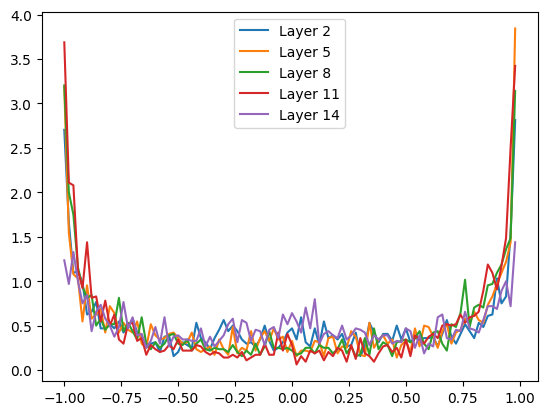

In [455]:
legends = []
for idx,l in enumerate(layers[:-1]):
    if isinstance(l , nn.Tanh):
        out = outs[idx+1]
        #print(out)
        mean, std = out.mean(), torch.sqrt(out.var())
        #print(mean, std)
        saturated_precentage = (out.abs() > 0.97).float().mean()*100
        print(f"Layer {idx}, mean:{mean}, std:{std}, {saturated_precentage=}")
        
        hy, hx = torch.histogram(input=out, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"Layer {idx}")

plt.legend(legends)
plt.show()

#### Analyzing the grad of the tanh activations

Layer 3, mean:1.0768417407769348e-11, std:0.003362185088917613
Layer 6, mean:-1.164153192248496e-12, std:0.003311625448986888
Layer 9, mean:-6.402842665786945e-12, std:0.003399621695280075
Layer 12, mean:7.566995641195007e-12, std:0.003492526011541486
Layer 15, mean:1.144751877291128e-05, std:0.005976570304483175


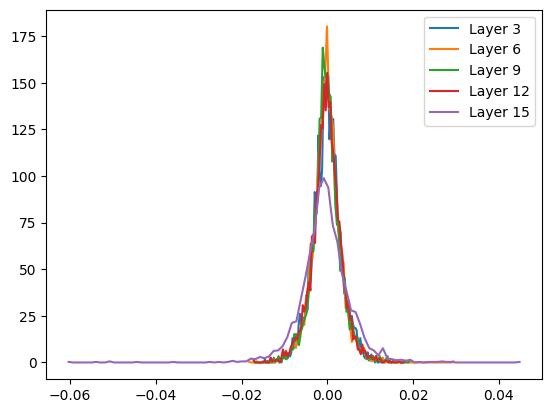

In [456]:
tanh_idx = []
for idx, l in enumerate(layers):
    if isinstance(l, nn.Tanh):
        tanh_idx.append(idx+1)

legends = []
for idx in tanh_idx:
    out = outs[idx].grad
    mean, std = out.mean(), torch.sqrt(out.var())
    print(f"Layer {idx}, mean:{mean}, std:{std}")
    
    hy, hx = torch.histogram(input=out, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f"Layer {idx}")

plt.legend(legends)
plt.show()
    

#### Analyzing the linear weight and it's grad to data ratio

grad_to_data_ratio is important because what's the scale of gradient updates compared to the scale of the parameter data, not the input data or something. Based on that we can decide to increase or decrease the learning rate, if the grad_to_data_ratio is very small then we can increase the learning rate and if it's very high then we can decrease the learning rate.

**p.grad** is how much times of the **p.data** of a single parameter

Layer  0 of weight:   (100, 30) | grad_mean -0.000067 | grad_std: 1.104557e-02 | grad/data ratio 1.961692e-02
Layer  3 of weight:  (100, 100) | grad_mean -0.000030 | grad_std: -1.452537e-04 | grad/data ratio 1.923200e-02
Layer  6 of weight:  (100, 100) | grad_mean +0.000090 | grad_std: 3.310005e-03 | grad/data ratio 2.049854e-02
Layer  9 of weight:  (100, 100) | grad_mean +0.000033 | grad_std: 3.573720e-03 | grad/data ratio 2.053133e-02
Layer 12 of weight:  (100, 100) | grad_mean +0.000060 | grad_std: -1.168721e-03 | grad/data ratio 2.015529e-02
Layer 15 of weight:   (27, 100) | grad_mean -0.000000 | grad_std: 5.927893e-04 | grad/data ratio 7.583068e-02


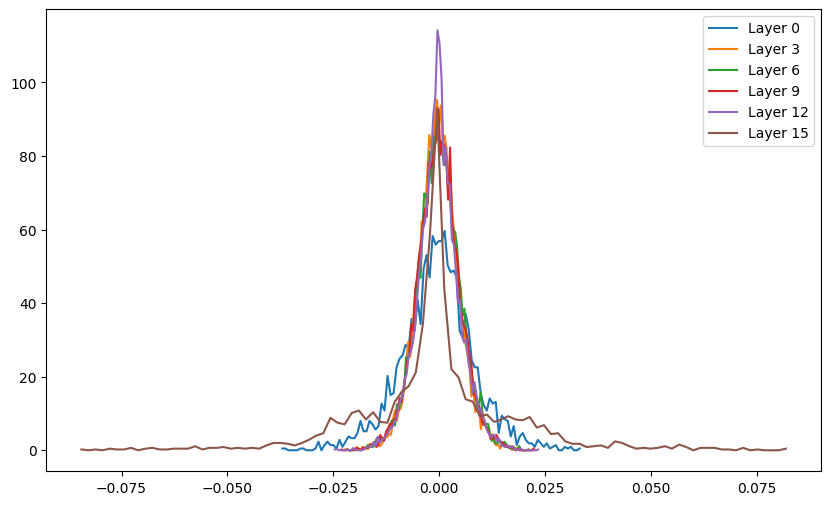

In [457]:
plt.figure(figsize=(10,6))
legends = []
for idx,l in enumerate(layers):
    if isinstance(l,nn.Linear):
        for p in l.parameters():
            if (p.ndim == 2):
                t = p.grad

                mean, std = out.mean(), torch.sqrt(out.var())
                grad_to_data_ratio = t.std()/p.std()
                print("Layer %2d of weight:%12s | grad_mean %+f | grad_std: %e | grad/data ratio %e" % (idx, tuple(p.shape), t.mean(), p.mean(), grad_to_data_ratio))
                            
                hy, hx = torch.histogram(input=t, density=True)
                plt.plot(hx[:-1].detach(), hy.detach())
                legends.append(f"Layer {idx}")


plt.legend(legends)
plt.show()

#### Analyzing the history of the ud ration of all 2dim parameters

In [458]:
len(uds), len(uds[0])

(6, 200000)

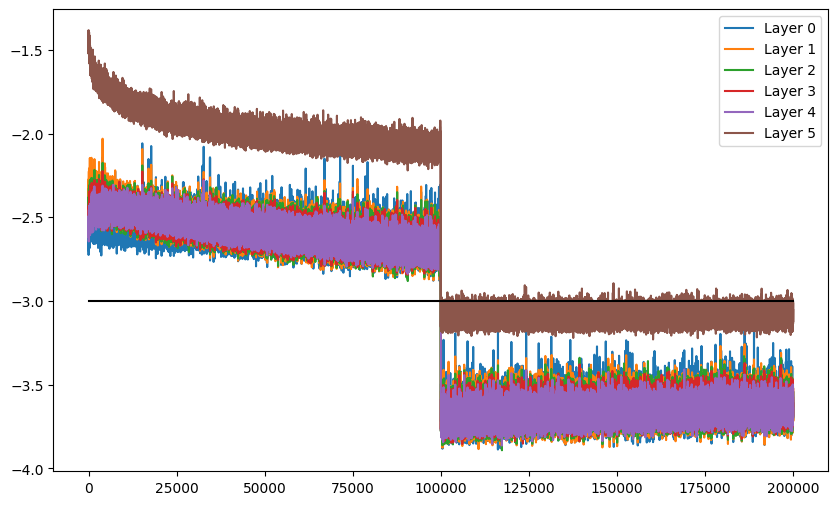

In [459]:
legends = []
plt.figure(figsize=(10,6))
for idx, ud_ratio in enumerate(uds):
    plt.plot(ud_ratio)
    legends.append(f"Layer {idx}")
plt.legend(legends)
plt.plot([0, len(uds[0])], [-3, -3], color='black')
plt.show()